In [2]:
import pyspiel
import numpy as np
import matplotlib.pyplot as plt
from open_spiel.python.algorithms import cfr
# You'll replace this with your custom EFR logic

game = pyspiel.load_game("leduc_poker")

### Baseline: CFR on Leduc Poker

We'll run standard CFR on Leduc Poker and log exploitability every 100 iterations.

In [15]:
from open_spiel.python import policy
from tqdm import trange


game = pyspiel.load_game("leduc_poker")
solver = cfr.CFRSolver(game)
exploitabilities_cfr = []

for i in trange(100, desc="CFR ITERATIONS"):
    solver.evaluate_and_update_policy()
    if i % 1 == 0:
        avg_policy = solver.average_policy()
        avg_policy_dict = avg_policy.to_dict()
        exploit = pyspiel.exploitability(game, avg_policy_dict)
        exploitabilities_cfr.append(exploit)


CFR ITERATIONS: 100%|██████████| 100/100 [00:24<00:00,  4.09it/s]


In [16]:
print(len(exploitabilities_cfr))

100


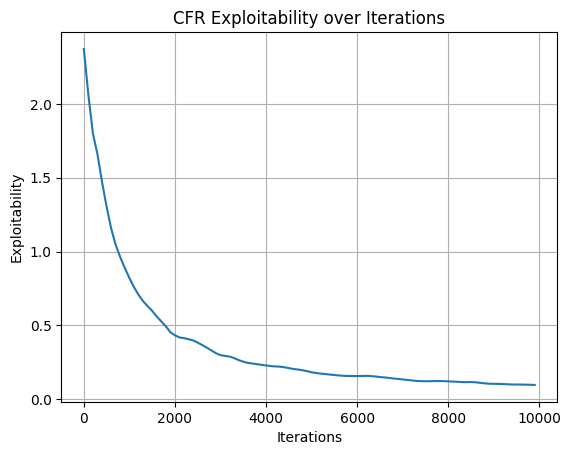

In [17]:
plt.plot(range(0, len(exploitabilities_cfr) * 100, 100), exploitabilities_cfr)
plt.xlabel("Iterations")
plt.ylabel("Exploitability")
plt.title("CFR Exploitability over Iterations")
plt.grid(True)
plt.show()

In [23]:
from open_spiel.python.algorithms.efr import EFRSolver

solver = EFRSolver(game, "tips") 
exploitabilities_efr = []

for i in trange(100, desc="EFR (TIPS) ITERATIONS"):
    solver.evaluate_and_update_policy()
    if i % 1 == 0:
        avg_policy = solver.average_policy()
        avg_policy_dict = avg_policy.to_dict()
        exploit = pyspiel.exploitability(game, avg_policy_dict)
        exploitabilities_efr.append(exploit)

EFR (TIPS) ITERATIONS:   7%|▋         | 7/100 [00:14<03:18,  2.14s/it]


KeyboardInterrupt: 

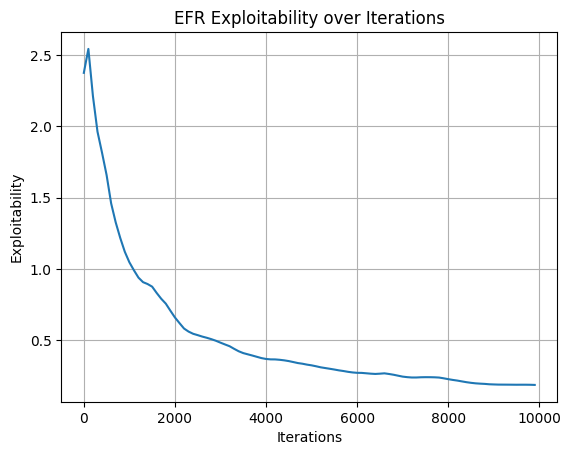

In [20]:
plt.plot(range(0, len(exploitabilities_efr) * 100, 100), exploitabilities_efr)
plt.xlabel("Iterations")
plt.ylabel("Exploitability")
plt.title("EFR Exploitability over Iterations")
plt.grid(True)
plt.show()

In [22]:
from open_spiel.python.algorithms.efr import EFRSolver

solver = EFRSolver(game, "blind cf") 
exploitabilities_bcf_efr = []

for i in trange(100, desc="EFR (Blind CF) ITERATIONS"):
    solver.evaluate_and_update_policy()
    if i % 1 == 0:
        avg_policy = solver.average_policy()
        avg_policy_dict = avg_policy.to_dict()
        exploit = pyspiel.exploitability(game, avg_policy_dict)
        exploitabilities_bcf_efr.append(exploit)


EFR (Blind CF) ITERATIONS: 100%|██████████| 100/100 [00:40<00:00,  2.47it/s]


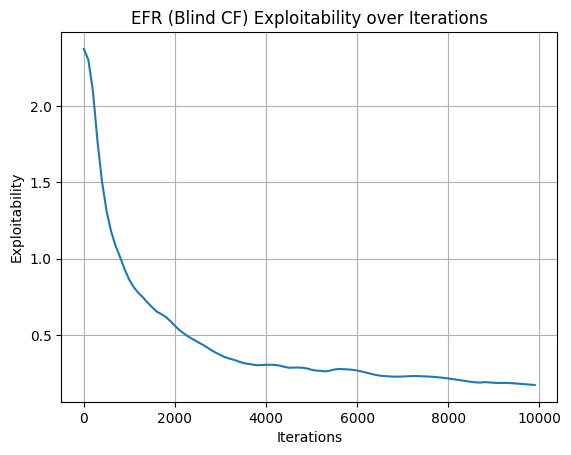

In [24]:
plt.plot(range(0, len(exploitabilities_bcf_efr) * 100, 100), exploitabilities_bcf_efr)
plt.xlabel("Iterations")
plt.ylabel("Exploitability")
plt.title("EFR (Blind CF) Exploitability over Iterations")
plt.grid(True)
plt.show()